In [7]:
import pandas as pd
df = pd.read_csv("../data/amazon_reviews.csv")
df.head()
df.shape

C:\Users\jagad\AppData\Local\Temp\ipykernel_13396\922620105.py:2: DtypeWarning: Columns (0: name, 1: reviews.didPurchase) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/amazon_reviews.csv")


(34660, 21)

In [8]:
df.columns
# df.isnull().sum()

Index(['id', 'name', 'asins', 'brand', 'categories', 'keys', 'manufacturer',
       'reviews.date', 'reviews.dateAdded', 'reviews.dateSeen',
       'reviews.didPurchase', 'reviews.doRecommend', 'reviews.id',
       'reviews.numHelpful', 'reviews.rating', 'reviews.sourceURLs',
       'reviews.text', 'reviews.title', 'reviews.userCity',
       'reviews.userProvince', 'reviews.username'],
      dtype='str')

In [9]:
df_Clean = df[[
    "name",
    "brand",
    "categories",
    "reviews.date",
    "reviews.rating",
    "reviews.title",
    "reviews.text"
]].copy()

df_Clean["brand"]=df_Clean["brand"].fillna("Unknown brand").str.strip().str.title()
df_Clean["categories"]=df_Clean["categories"].fillna("Unknown category").str.strip().str.lower()
df_Clean["name"]=df_Clean["name"].fillna("Unknown name").str.strip()
df_Clean["reviews.title"] = df_Clean["reviews.title"].fillna("Unknown Title").str.strip()
df_Clean = df_Clean.dropna(subset=["reviews.rating"])
df_Clean=df_Clean.dropna(subset=["reviews.text"])
df_Clean["reviews.date"] = pd.to_datetime(df_Clean["reviews.date"],errors="coerce")

In [10]:
df_Clean["search_text"] = (
    df_Clean["name"].astype(str)
    + " "
    + df_Clean["reviews.title"].astype(str)
    + " "
    + df_Clean["reviews.text"].astype(str)
)

In [11]:
print(df_Clean.shape)
df_Clean.isnull().sum()
df_Clean.to_csv("../data/clean_amazon_reviews.csv", index=False)

(34626, 8)


In [13]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)
sample_text = df_Clean["search_text"].iloc[0]
print(sample_text[:200])
embedding = model.encode(sample_text)
print(type(embedding))
print(len(embedding))

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta Kindle This product so far has not disappointed. My children love to use it and I like the ability to monitor co
<class 'numpy.ndarray'>
384


In [16]:
subset = df_Clean.head(1000)
embeddings = model.encode(
    subset["search_text"].tolist(),
    show_progress_bar=True
)
print(type(embeddings))
print(embeddings.shape)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

<class 'numpy.ndarray'>
(1000, 384)


In [50]:
import chromadb
client = chromadb.Client()
print("Client Created")
collection = client.get_or_create_collection(
    name="amazon_reviews"
)
print("Collection Created")
print(subset.shape)
print(embeddings.shape)
collection.add(
    ids=[str(i) for i in range(len(subset))],
    documents=subset["search_text"].tolist(),
    embeddings=embeddings.tolist(),
    metadatas=[
        {
            "name": str(row["name"]),
            "brand": str(row["brand"]),
            "rating": float(row["reviews.rating"]),
            "category": str(row["categories"])
        }
        for _, row in subset.iterrows()
    ]
)
query = "voice assistant for home"
query_embedding = model.encode(query)
results = collection.query(
    query_embeddings=[query_embedding.tolist()],
    n_results=5
)


for i in range(len(results["documents"][0])):
    print("=" * 80)
    print("Product:", results["metadatas"][0][i]["name"])
    print("Brand:", results["metadatas"][0][i]["brand"])
    print("Rating:", results["metadatas"][0][i]["rating"])
    print("Review:", results["documents"][0][i][:400])

Client Created
Collection Created
(1000, 8)
(1000, 384)
Product: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
Brand: Amazon
Rating: 4.0
Review: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta Great Screen For Echo I bought it as the display for my Echo. Turning on Voicecast routes information to the tablet with the voice reaponse. It'S been exactly what I hoped it would be and the price was right.
Product: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
Brand: Amazon
Rating: 4.0
Review: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta Can't beat if for the price What I expected. A better then budget tablet ata good price. Bought for the integration with Alexa and it works well, more info about your Alexa request will show up automatically on the tablet.
Product: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes S

In [51]:
client.delete_collection("amazon_reviews")

collection = client.get_or_create_collection(
    name="amazon_reviews"
)

print("Fresh Collection Created")

Fresh Collection Created


In [44]:
collection.add(
    ids=[str(i) for i in range(len(subset))],
    documents=subset["search_text"].tolist(),
    embeddings=embeddings.tolist(),
    metadatas=[
        {
            "name": str(row["name"]),
            "brand": str(row["brand"]),
            "rating": float(row["reviews.rating"]),
            "category": str(row["categories"])
        }
        for _, row in subset.iterrows()
    ]
)

print("Inserted with metadata successfully")

Inserted with metadata successfully


In [ ]:
query = "tablet for kids"

query_embedding = model.encode(query)

results = collection.query(
    query_embeddings=[query_embedding.tolist()],
    n_results=5
)
# for i in range(len(results["documents"][0])):
#     print("=" * 80)
#     print("Product:", results["metadatas"][0][i]["name"])
#     print("Brand:", results["metadatas"][0][i]["brand"])
#     print("Rating:", results["metadatas"][0][i]["rating"])
#     print("Review:", results["documents"][0][i][:400])

print(results["distances"])
for i in range(len(results["documents"][0])):
    
    print("=" * 80)
    
    print("Product:",
          results["metadatas"][0][i]["name"])
    
    print("Rating:",
          results["metadatas"][0][i]["rating"])
    
    print("Distance:",
          round(results["distances"][0][i], 4))
    
    print("Review:")
    print(results["documents"][0][i][:300])

[[]]


In [46]:
# print(results.keys())
for i in range(len(results["documents"][0])):

    rating = results["metadatas"][0][i]["rating"]

    if rating >= 4.5:

        print("=" * 80)

        print("Product:",
              results["metadatas"][0][i]["name"])

        print("Rating:", rating)

        print("Distance:",
              round(results["distances"][0][i], 4))

Product: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
Rating: 5.0
Distance: 0.6556
Product: All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
Rating: 5.0
Distance: 0.6592


In [38]:
results_list = []
for i in range(len(results["documents"][0])):

    distance = results["distances"][0][i]
    rating = results["metadatas"][0][i]["rating"]

    score = (1 - distance) * 0.7 + (rating / 5) * 0.3

    results_list.append({
        "product": results["metadatas"][0][i]["name"],
        "rating": rating,
        "distance": distance,
        "score": score
    })

results_list

[{'product': 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta',
  'rating': 5.0,
  'distance': 0.6555687189102173,
  'score': 0.5411018967628478},
 {'product': 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta',
  'rating': 5.0,
  'distance': 0.6592140793800354,
  'score': 0.5385501444339752},
 {'product': 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta',
  'rating': 4.0,
  'distance': 0.6926794052124023,
  'score': 0.45512441635131834},
 {'product': 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta',
  'rating': 4.0,
  'distance': 0.7033729553222656,
  'score': 0.447638931274414},
 {'product': 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta',
  'rating': 4.0,
  'distance': 0.7176042795181274,
  'score': 0.43767700433731077}]

In [39]:
results_list = sorted(
    results_list,
    key=lambda x: x["score"],
    reverse=True
)

results_list

[{'product': 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta',
  'rating': 5.0,
  'distance': 0.6555687189102173,
  'score': 0.5411018967628478},
 {'product': 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta',
  'rating': 5.0,
  'distance': 0.6592140793800354,
  'score': 0.5385501444339752},
 {'product': 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta',
  'rating': 4.0,
  'distance': 0.6926794052124023,
  'score': 0.45512441635131834},
 {'product': 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta',
  'rating': 4.0,
  'distance': 0.7033729553222656,
  'score': 0.447638931274414},
 {'product': 'All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta',
  'rating': 4.0,
  'distance': 0.7176042795181274,
  'score': 0.43767700433731077}]

In [53]:
for item in results_list:
    print("=" * 80)
    print("Product :", item["product"])
    print("Rating  :", item["rating"])
    print("Distance:", round(item["distance"], 4))
    print("Score   :", round(item["score"], 4))

Product : All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
Rating  : 5.0
Distance: 0.6556
Score   : 0.5411
Product : All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
Rating  : 5.0
Distance: 0.6592
Score   : 0.5386
Product : All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
Rating  : 4.0
Distance: 0.6927
Score   : 0.4551
Product : All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
Rating  : 4.0
Distance: 0.7034
Score   : 0.4476
Product : All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta
Rating  : 4.0
Distance: 0.7176
Score   : 0.4377


In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
review = df_Clean["reviews.text"].iloc[0]

print(review)
print(analyzer.polarity_scores(review))

def get_sentiment(text):
    score = analyzer.polarity_scores(str(text))["compound"]

    if score >= 0.05:
        return "Positive"
    elif score <= -0.05:
        return "Negative"
    else:
        return "Neutral"
df_Clean["sentiment"] = df_Clean["reviews.text"].apply(get_sentiment)
df_Clean["sentiment"].value_counts()
sentiment_percent = (
    df_Clean["sentiment"]
    .value_counts(normalize=True)
    * 100
)
print(sentiment_percent)

This product so far has not disappointed. My children love to use it and I like the ability to monitor control what content they see with ease.
{'neg': 0.0, 'neu': 0.61, 'pos': 0.39, 'compound': 0.9194}
sentiment
Positive    90.177901
Negative     5.461214
Neutral      4.360885
Name: proportion, dtype: float64


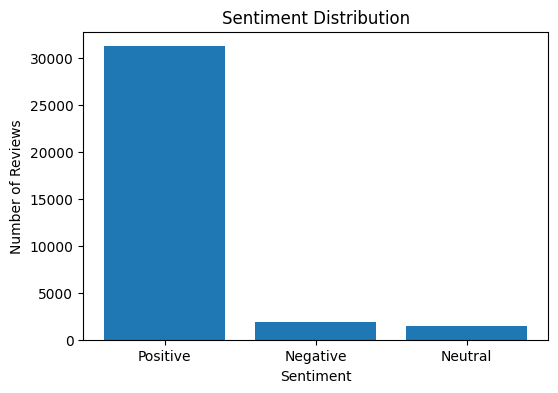

sentiment
Negative    3.794818
Neutral     4.330464
Positive    4.644676
Name: reviews.rating, dtype: float64

In [60]:
import matplotlib.pyplot as plt
sentiment_counts = df_Clean["sentiment"].value_counts()
plt.figure(figsize=(6,4))
plt.bar(
    sentiment_counts.index,
    sentiment_counts.values
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")

plt.show()
df_Clean.groupby("sentiment")["reviews.rating"].mean()

In [62]:
# df_Clean[
#     df_Clean["sentiment"] == "Negative"
# ][[
#     "reviews.rating",
#     "reviews.text"
# ]].head(10)

pd.crosstab(
    df_Clean["reviews.rating"],
    df_Clean["sentiment"]
)

sentiment,Negative,Neutral,Positive
reviews.rating,,,
1.0,168,58,184
2.0,163,49,190
3.0,303,138,1058
4.0,512,356,7673
5.0,745,909,22120


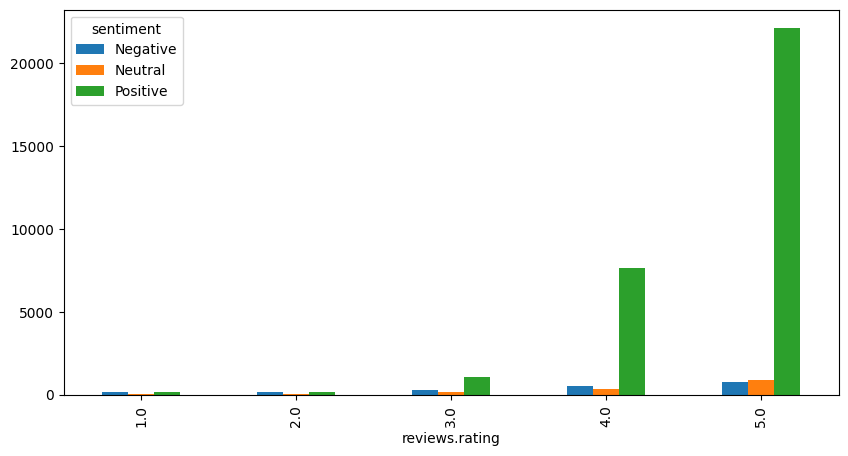

In [ ]:
import matplotlib.pyplot as plt

cross_tab = pd.crosstab(
    df_Clean["reviews.rating"],
    df_Clean["sentiment"]
)

ax = cross_tab.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Rating vs Sentiment")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [73]:
brand_stats = (
    df_Clean
    .groupby("brand")
    .agg(
        avg_rating=("reviews.rating", "mean"),
        review_count=("reviews.rating", "count")
    )
)

brand_stats = brand_stats[
    brand_stats["review_count"] >= 50
]

brand_stats.sort_values(
    "avg_rating",
    ascending=False
).head(10)

,avg_rating,review_count
brand,,
Amazon Fire Tv,4.707278,5056
Amazon,4.564706,28668
Amazon Fire,4.558594,256
Amazon Echo,4.531447,636


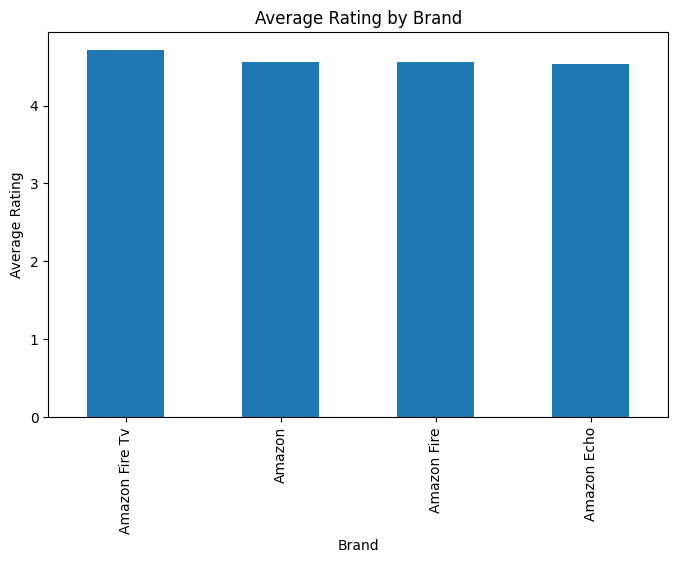

brand
Amazon                          28668
Amazon Fire Tv                   5056
Amazon Echo                       636
Amazon Fire                       256
Amazon Digital Services Inc.       10
Name: count, dtype: int64

In [ ]:
top_brands = brand_stats.sort_values(
    "avg_rating",
    ascending=False
)

top_brands["avg_rating"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Rating by Brand")
plt.ylabel("Average Rating")
plt.xlabel("Brand")
plt.show()
brand_sentiment = pd.crosstab(
    df_Clean["brand"],
    df_Clean["sentiment"]
)

brand_sentiment["positive_rate"] = (
    brand_sentiment["Positive"]
    /
    brand_sentiment.sum(axis=1)
) * 100

brand_sentiment.sort_values(
    "positive_rate",
    ascending=False
)



In [ ]:
product_stats = (
    df_Clean
    .groupby("name")
    .agg(
        avg_rating=("reviews.rating", "mean"),
        review_count=("reviews.rating", "count")
    )
)

product_stats = product_stats[
    product_stats["review_count"] >= 100
]

product_stats.sort_values(
    "avg_rating",
    ascending=False
).head(10)


,avg_rating,review_count
name,,
"All-New Kindle E-reader - Black, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers,,",4.429245,212
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",4.453293,10962
"Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,,,\r\nAmazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,,,",4.458937,207
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",4.510386,1685
"Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,",4.550823,1033
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Magenta",4.568493,146
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",4.586709,2814
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",4.600543,368
"Echo (White),,,\r\nEcho (White),,,",4.645512,3309


In [81]:

product_stats.sort_values(
    "avg_rating",
    ascending=True
).head(10)

,avg_rating,review_count
name,,
"All-New Kindle E-reader - Black, 6 Glare-Free Touchscreen Display, Wi-Fi - Includes Special Offers,,",4.429245,212
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Magenta",4.453293,10962
"Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,,,\r\nAmazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders,,,",4.458937,207
"Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Green Kid-Proof Case",4.510386,1685
"Brand New Amazon Kindle Fire 16gb 7 Ips Display Tablet Wifi 16 Gb Blue,,,",4.550823,1033
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 32 GB - Includes Special Offers, Magenta",4.568493,146
"All-New Fire HD 8 Tablet, 8 HD Display, Wi-Fi, 16 GB - Includes Special Offers, Magenta",4.586709,2814
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",4.600543,368
"Echo (White),,,\r\nEcho (White),,,",4.645512,3309


In [ ]:
product_sentiment = pd.crosstab(
    df_Clean["name"],
    df_Clean["sentiment"]
)

product_sentiment["positive_rate"] = (
    product_sentiment["Positive"]
    /
    product_sentiment.sum(axis=1)
) * 100

product_sentiment.sort_values(
    "positive_rate",
    ascending=False
).head(10)



,avg_rating,review_count
name,,
"Amazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Special Offers - Silver Aluminum,,,\r\nAmazon Fire Hd 10 Tablet, Wi-Fi, 16 Gb, Special Offers - Silver Aluminum,,,",4.773438,128
"Amazon Kindle Paperwhite - eBook reader - 4 GB - 6 monochrome Paperwhite - touchscreen - Wi-Fi - black,,,",4.755038,3176
"Kindle Voyage E-reader, 6 High-Resolution Display (300 ppi) with Adaptive Built-in Light, PagePress Sensors, Wi-Fi - Includes Special Offers,",4.743103,580
"Amazon Fire Hd 8 8in Tablet 16gb Black B018szt3bk 6th Gen (2016) Android,,,\r\nAmazon Fire Hd 8 8in Tablet 16gb Black B018szt3bk 6th Gen (2016) Android,,,",4.740741,135
"Amazon - Amazon Tap Portable Bluetooth and Wi-Fi Speaker - Black,,,\r\nAmazon - Amazon Tap Portable Bluetooth and Wi-Fi Speaker - Black,,,",4.729560,318
Unknown name,4.664743,6759
"Amazon Fire Tv,,,\r\nAmazon Fire Tv,,,",4.650178,2527
"Echo (White),,,\r\nEcho (White),,,",4.645512,3309
"Fire Tablet, 7 Display, Wi-Fi, 8 GB - Includes Special Offers, Black",4.600543,368


In [91]:
product_stats.sort_values(
    "avg_rating",
    ascending=False
).head(10)
positive_products = product_sentiment[
    product_sentiment.sum(axis=1) >= 100
].sort_values(
    "positive_rate",
    ascending=False
)

positive_products.head(10)
product_sentiment["negative_rate"] = (
    product_sentiment["Negative"]
    /
    product_sentiment.sum(axis=1)
) * 100

In [109]:
df_Clean["name"] = (
    df_Clean["name"]
    .str.replace("\r\n", " ", regex=False)
    .str.replace(",,,", "", regex=False)
    .str.strip()
)

product_df = df_Clean[
    df_Clean["name"] != "Unknown name"
]

product_sentiment = pd.crosstab(
    product_df["name"],
    product_df["sentiment"]
)

product_sentiment["positive_rate"] = (
    product_sentiment["Positive"]
    /
    product_sentiment.sum(axis=1)
) * 100

product_sentiment[
    product_sentiment.sum(axis=1) >= 100
].sort_values(
    "positive_rate",
    ascending=False
).head(10)

sentiment,Negative,Neutral,Positive,positive_rate
name,,,,
Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders Amazon 9W PowerFast Official OEM USB Charger and Power Adapter for Fire Tablets and Kindle eReaders,0,0,36,100.0
"Amazon - Kindle Voyage - 4GB - Wi-Fi + 3G - Black Fire HD 8 Tablet with Alexa, 8 HD Display, 16 GB, Tangerine - with Special Offers"",",0,0,1,100.0
"Amazon Kindle Touch Leather Case (4th Generation - 2011 Release), Olive Green Amazon Kindle Touch Leather Case (4th Generation - 2011 Release), Olive Green",0,0,3,100.0
Amazon Kindle Fire 5ft USB to Micro-USB Cable (works with most Micro-USB Tablets) Amazon Kindle Fire 5ft USB to Micro-USB Cable (works with most Micro-USB Tablets),0,0,4,100.0
Amazon Kindle Lighted Leather Cover Amazon Kindle Lighted Leather Cover,0,0,2,100.0
"Amazon Fire Tv Kindle Dx Leather Cover, Black (fits 9.7 Display, Latest and 2nd Generation Kindle Dxs)"",,",0,0,1,100.0
"Amazon Fire Kids Edition Tablet, 7 Display, Wi-Fi, 16 GB, Blue Kid-Proof Case - Blue",0,0,6,100.0
"Amazon Fire Hd 6 Standing Protective Case(4th Generation - 2014 Release), Cayenne Red Amazon Fire Hd 6 Standing Protective Case(4th Generation - 2014 Release), Cayenne Red",0,0,6,100.0
"Amazon Fire Hd 6 Standing Protective Case(4th Generation - 2014 Release), Cayenne Red Amazon 5W USB Official OEM Charger and Power Adapter for Fire Tablets and Kindle eReaders",0,0,1,100.0


In [ ]:
positive_products = product_sentiment[
    product_sentiment.sum(axis=1) >= 100
].sort_values(
    "positive_rate",
    ascending=False
)

positive_products.head(10)

product_sentiment["negative_rate"] = (
    product_sentiment["Negative"]
    /
    product_sentiment.sum(axis=1)
) * 100

negative_products = product_sentiment[
    product_sentiment.sum(axis=1) >= 100
].sort_values(
    "negative_rate",
    ascending=False
)

negative_products.head(10)


0   2017-01-13 00:00:00+00:00
1   2017-01-13 00:00:00+00:00
2   2017-01-13 00:00:00+00:00
3   2017-01-13 00:00:00+00:00
4   2017-01-12 00:00:00+00:00
Name: reviews.date, dtype: datetime64[us, UTC]

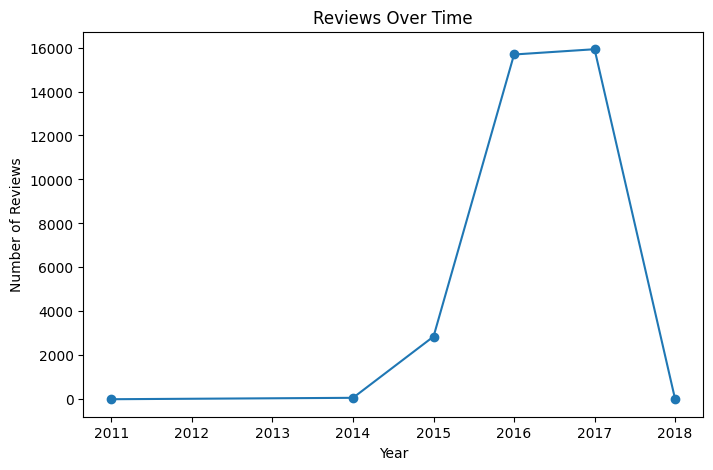

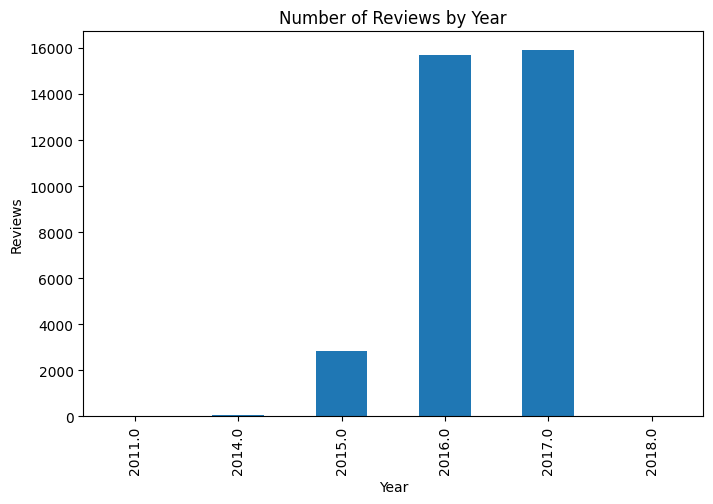

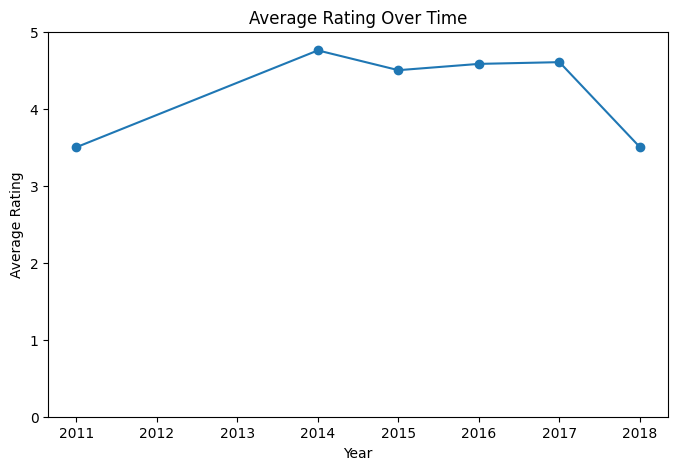

In [110]:
df_Clean["reviews.date"].head()
df_Clean["year"] = df_Clean["reviews.date"].dt.year
df_Clean["year"].value_counts().sort_index()
reviews_per_year = (
    df_Clean["year"]
    .value_counts()
    .sort_index()
)

reviews_per_year.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Reviews Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Reviews")
plt.show()
df_Clean["year"].value_counts().sort_index()

reviews_per_year = (
    df_Clean["year"]
    .value_counts()
    .sort_index()
)

reviews_per_year.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Number of Reviews by Year")
plt.xlabel("Year")
plt.ylabel("Reviews")
plt.show()

yearly_ratings = (
    df_Clean
    .groupby("year")["reviews.rating"]
    .mean()
)
yearly_ratings

yearly_ratings.plot(
    kind="line",
    marker="o",
    figsize=(8,5)
)

plt.title("Average Rating Over Time")
plt.xlabel("Year")
plt.ylabel("Average Rating")
plt.ylim(0, 5)
plt.show()